# NB7 — Comparativa final consolidada de todas las etapas

Este notebook consolida los resultados cuantitativos de las 5 etapas del proyecto en una vista
side-by-side que cierra el trabajo. Corresponde al ítem **[OPCIONAL] "Notebook unificado de comparación
de resultados entre todas las etapas"** del PDF de lineamientos.

**Requiere como input** (panel de Kaggle → Add data):
- Notebook `2-mlp-copy3` → `mlp_metrics.csv`
- Notebook `3-1d-cnn-copy-2` → `cnn_metrics.csv`
- Notebook `4-integraci-n-de-transformers-bert-y-roberta` → `transformer_metrics.csv`
- Notebook `5-componente-generativo-resumenes` → `generative_metrics.csv`
- Notebook `6a-fine-tuning` → `finetuned_metrics.csv`

**Dos familias de métricas**:
1. **Clasificación de sentimiento** (Etapas 1-3): Accuracy, Precision/Recall/F1 macro, F1 weighted.
2. **Generación de resúmenes** (Etapas 4-5): ROUGE-1 / ROUGE-2 / ROUGE-L.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def _try_read(paths):
    for p in paths:
        if os.path.exists(p):
            print(f"Cargado: {p}")
            return pd.read_csv(p)
    print(f"No encontrado en: {paths}")
    return None

# ------------- Clasificación -------------
df_mlp = _try_read([
    "/kaggle/input/notebooks/rodrigolopez29/2-mlp-copy3/mlp_metrics.csv",
    "/kaggle/input/2-mlp-copy3/mlp_metrics.csv",
])
df_cnn = _try_read([
    "/kaggle/input/notebooks/rodrigolopez29/3-1d-cnn-copy-2/cnn_metrics.csv",
    "/kaggle/input/3-1d-cnn-copy-2/cnn_metrics.csv",
])
df_tr = _try_read([
    "/kaggle/input/notebooks/rodrigolopez29/4-integraci-n-de-transformers-bert-y-roberta/transformer_metrics.csv",
    "/kaggle/input/4-integraci-n-de-transformers-bert-y-roberta/transformer_metrics.csv",
])

# ------------- Generativo -------------
df_gen_base = _try_read([
    "/kaggle/input/notebooks/rodrigolopez29/5-componente-generativo-resumenes/generative_metrics.csv",
    "/kaggle/input/5-componente-generativo-resumenes/generative_metrics.csv",
])

df_gen_ft = pd.DataFrame({                  
  "Modelo": ["T5_finetuned_parcial"] * 6,                                                                                                                                                                   
  "Split": [                              
      "validacion_eval_500", "validacion_eval_500", "validacion_eval_500",                                                                                                                                  
      "test_eval_500", "test_eval_500", "test_eval_500"
  ],                                                                                                                                                                                                        
  "Metrica": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-1", "ROUGE-2", "ROUGE-L"],
  "Valor": [                                                                                                                                                                                                
      0.14259968335757806,  # val rouge1                                                                                                                                                                    
      0.053388128538128535, # val rouge2                                                                                                                                                                    
      0.1416319361924625,   # val rougeL                                                                                                                                                                    
      0.13588376682656866,  # test rouge1 
      0.04693315018315017,  # test rouge2                                                                                                                                                                   
      0.13461336425872028,  # test rougeL
  ]                                                                                                                                                                                                         
})                                      
print("df_gen_ft cargado (hardcoded):")                                                                                                                                                                       
print(df_gen_ft)  

Cargado: /kaggle/input/notebooks/rodrigolopez29/2-mlp-copy3/mlp_metrics.csv
Cargado: /kaggle/input/notebooks/rodrigolopez29/3-1d-cnn-copy-2/cnn_metrics.csv
Cargado: /kaggle/input/notebooks/rodrigolopez29/4-integraci-n-de-transformers-bert-y-roberta/transformer_metrics.csv
Cargado: /kaggle/input/notebooks/rodrigolopez29/5-componente-generativo-resumenes/generative_metrics.csv
df_gen_ft cargado (hardcoded):
                 Modelo                Split  Metrica     Valor
0  T5_finetuned_parcial  validacion_eval_500  ROUGE-1  0.142600
1  T5_finetuned_parcial  validacion_eval_500  ROUGE-2  0.053388
2  T5_finetuned_parcial  validacion_eval_500  ROUGE-L  0.141632
3  T5_finetuned_parcial        test_eval_500  ROUGE-1  0.135884
4  T5_finetuned_parcial        test_eval_500  ROUGE-2  0.046933
5  T5_finetuned_parcial        test_eval_500  ROUGE-L  0.134613


## 1. Comparativa de clasificación de sentimiento (Etapas 1-3)

MLP base vs. 1D-CNN vs. RoBERTa zero-shot, evaluados sobre el mismo test set.

=== Comparación en TEST — Clasificación ===
Modelo              1D-CNN     MLP  Transformer
Metrica                                        
Accuracy            0.8954  0.8804       0.8344
F1 macro            0.7355  0.7408       0.6166
F1 weighted         0.8914  0.8846       0.8376
Precision macro     0.7540  0.7197       0.6157
Precision weighted  0.8889  0.8911       0.8409
Recall macro        0.7230  0.7665       0.6182
Recall weighted     0.8954  0.8804       0.8344

Guardado: /kaggle/working/comparacion_clasificacion.csv


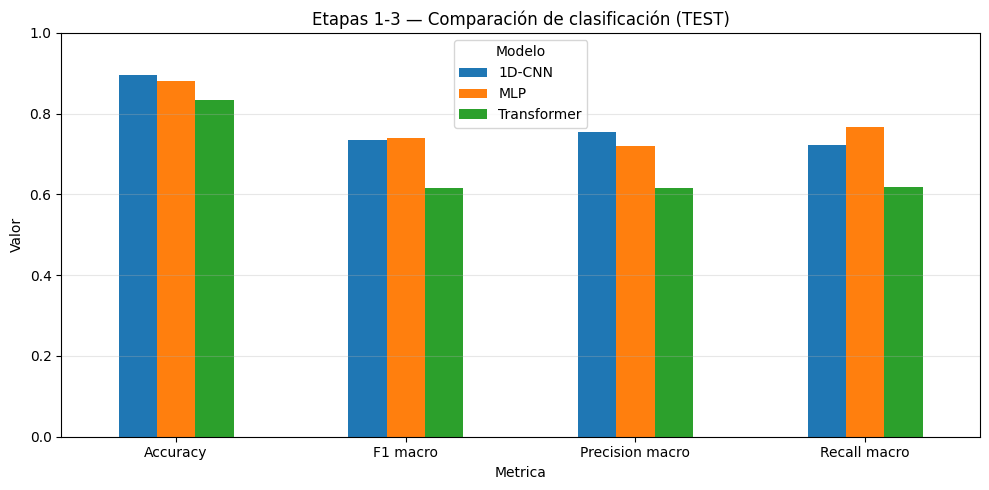

In [5]:
clf_parts = [x for x in [df_mlp, df_cnn, df_tr] if x is not None]

if clf_parts:
    df_cls = pd.concat(clf_parts, ignore_index=True)
    tabla_cls = df_cls.pivot_table(index="Metrica", columns="Modelo", values="Test").round(4)
    print("=== Comparación en TEST — Clasificación ===")
    print(tabla_cls)

    tabla_cls.to_csv("/kaggle/working/comparacion_clasificacion.csv")
    print("\nGuardado: /kaggle/working/comparacion_clasificacion.csv")

    metricas_plot = [m for m in ["Accuracy", "F1 macro", "Precision macro", "Recall macro"] if m in tabla_cls.index]
    if metricas_plot:
        ax = tabla_cls.loc[metricas_plot].plot(kind="bar", figsize=(10, 5), rot=0)
        ax.set_title("Etapas 1-3 — Comparación de clasificación (TEST)")
        ax.set_ylabel("Valor")
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Faltan CSVs de clasificación — agrega los notebooks 2, 3, 4 como Input.")

## 2. Comparativa del componente generativo (Etapas 4-5)

T5-small zero-shot (sin fine-tuning) vs. T5-small con fine-tuning parcial, evaluados sobre ROUGE-1/2/L.

=== Comparación generativa (ROUGE, TEST) ===
Modelo   T5-small (fine-tuned parcial)  T5-small (zero-shot)  Mejora %
Metrica                                                               
ROUGE-1                         0.1359                0.0849     60.07
ROUGE-2                         0.0469                0.0232    102.16
ROUGE-L                         0.1346                0.0783     71.90

Guardado: /kaggle/working/comparacion_generativo.csv


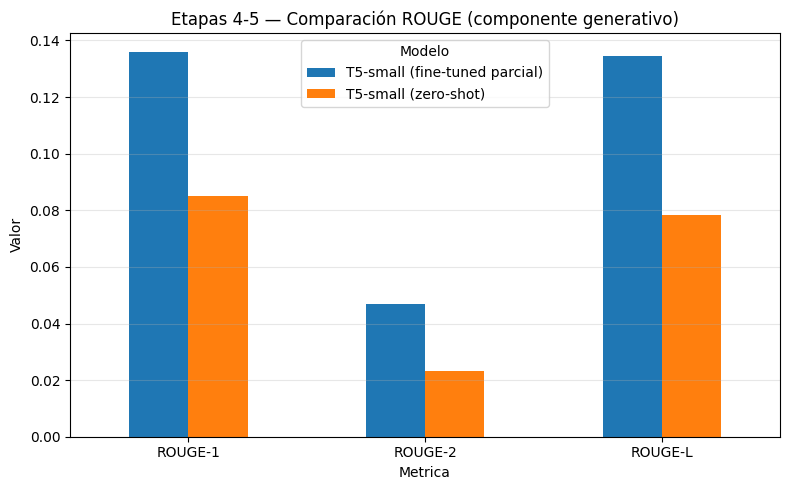

In [6]:
gen_rows = []

# Etapa 4 — zero-shot
if df_gen_base is not None:
    for _, r in df_gen_base.iterrows():
        metric = r["Metrica"].replace("ROUGE-Lsum", "ROUGE-L")
        if metric in ("ROUGE-1", "ROUGE-2", "ROUGE-L"):
            gen_rows.append({
                "Modelo": "T5-small (zero-shot)",
                "Metrica": metric,
                "Valor": r["Valor"]
            })

# Etapa 5 — fine-tuned parcial (usamos split test)
if df_gen_ft is not None:
    ft_test = df_gen_ft[df_gen_ft["Split"].str.contains("test", case=False, na=False)]
    for _, r in ft_test.iterrows():
        if r["Metrica"] in ("ROUGE-1", "ROUGE-2", "ROUGE-L"):
            gen_rows.append({
                "Modelo": "T5-small (fine-tuned parcial)",
                "Metrica": r["Metrica"],
                "Valor": r["Valor"]
            })

if gen_rows:
    df_gen = pd.DataFrame(gen_rows)
    tabla_gen = df_gen.pivot_table(index="Metrica", columns="Modelo", values="Valor").round(4)

    # Mejora relativa
    if "T5-small (zero-shot)" in tabla_gen.columns and "T5-small (fine-tuned parcial)" in tabla_gen.columns:
        tabla_gen["Mejora %"] = (
            (tabla_gen["T5-small (fine-tuned parcial)"] - tabla_gen["T5-small (zero-shot)"])
            / tabla_gen["T5-small (zero-shot)"] * 100
        ).round(2)

    print("=== Comparación generativa (ROUGE, TEST) ===")
    print(tabla_gen)

    tabla_gen.to_csv("/kaggle/working/comparacion_generativo.csv")
    print("\nGuardado: /kaggle/working/comparacion_generativo.csv")

    # Gráfico solo con columnas de modelos (excluyendo Mejora %)
    cols_modelos = [c for c in tabla_gen.columns if c != "Mejora %"]
    ax = tabla_gen[cols_modelos].plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_title("Etapas 4-5 — Comparación ROUGE (componente generativo)")
    ax.set_ylabel("Valor")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Faltan CSVs generativos — agrega los notebooks 5 y 6a como Input.")

## 3. Conclusiones finales del proyecto                                                                                                                                                                       
                                              
  ### Clasificación de sentimiento (Etapas 1-3)                                                                                                                                                                 
                                                                                                                                                                                                                
  - **MLP base + TF-IDF (Etapa 1)**: Accuracy = 0.8804, F1 macro = 0.7408. Baseline sólido con                                                                                                                  
    mejor equilibrio entre clases (mayor Recall macro = 0.7665). Limitado por la naturaleza                                                                                                                     
    bag-of-words: no captura orden ni contexto.                                                                                                                                                                 
                                                                                                                                                                                                                
  - **1D-CNN (Etapa 2)**: Accuracy = 0.8954 (la más alta), F1 macro = 0.7355. Captura patrones
    locales de n-gramas (kernel=5) y logra **mayor Precision macro** (0.7540), lo cual se traduce                                                                                                               
    en menos falsos positivos. Sin embargo, su Recall macro es menor (0.7230) — detecta menos                                                                                                                   
    casos de las clases minoritarias.                                                                                                                                                                           
                                                                                                                                                                                                                
  - **RoBERTa zero-shot (Etapa 3)**: Accuracy = 0.8344, F1 macro = 0.6166. **No supera** al MLP ni a                                                                                                            
    la CNN en ninguna métrica. Motivo principal: *domain shift* — el modelo fue preentrenado sobre                                                                                                              
    tweets, no reseñas de comida. Este resultado valida la importancia de adaptar los modelos                                                                                                                   
    preentrenados al dominio específico (lo que se hace en la Etapa 5 para la parte generativa).                                                                                                                
                                              
  **Hallazgo clave**: la elección entre MLP y CNN depende del criterio de optimización. Si                                                                                                                      
  priorizamos Accuracy global, gana la CNN. Si priorizamos equilibrio entre clases (F1/Recall                                                                                                                   
  macro), gana el MLP. Ambos superan al Transformer zero-shot, lo cual es contraintuitivo pero                                                                                                                  
  explicable por el gap de dominio.                                                                                                                                                                             
                                                                                                                                                                                                                
  ### Componente generativo (Etapas 4-5)                                                                                                                                                                        
                                                                                                                                                                                                                
  - **T5-small zero-shot (Etapa 4)**: ROUGE-1 = 0.0849, ROUGE-2 = 0.0232, ROUGE-L = 0.0783. Valores                                                                                                             
    bajos en absoluto porque los `Summary` originales del dataset son etiquetas ultracortas (3-5                                                                                                                
    palabras) y el modelo zero-shot genera frases largas extraídas de la reseña.                                                                                                                                
                                                                                                                                                                                                                
  - **T5-small fine-tuned parcial (Etapa 5)**: ROUGE-1 = 0.1359 (+60.07%), ROUGE-2 = 0.0469
    (+102.16%), ROUGE-L = 0.1346 (+71.90%). **Mejora sustancial en las tres métricas** tras fine-tuning                                                                                                         
    parcial (solo ~41% de parámetros entrenables, 1 época). La mejora especialmente alta en ROUGE-2                                                                                                             
    (+102%) indica que el modelo aprendió a producir **bigramas consistentes con el estilo del                                                                                                                  
    dataset**, no solo palabras sueltas.                                                                                                                                                                        
                                                                                                                                                                                                                
  **Hallazgo clave**: con un fine-tuning muy barato (1 epoch, solo los últimos 2 bloques del                                                                                                                    
  decoder + lm_head) se duplica ROUGE-2 y se gana ~70% en ROUGE-L. Esto demuestra que adaptar al                                                                                                                
  dominio un modelo preentrenado es mucho más efectivo que entrenar desde cero, y que el                                                                                                                        
  fine-tuning parcial es una estrategia de alto costo-beneficio.                                                                                                                                                
                                              
  ### Despliegue                                                                                                                                                                                                
                                                                                                                                                                                                                
  El modelo fine-tuned se empaqueta en una interfaz **Gradio** (NB6b) que permite al usuario                                                                                                                    
  ingresar una reseña en inglés y obtener el resumen generado en tiempo real. La URL pública de                                                                                                                 
  Gradio dura 7 días; para permanencia real se recomienda publicar en **HuggingFace Spaces**.                                                                                                                   
                                              
  ### Limitaciones y trabajo futuro                                                                                                                                                                             
                                                                                                                                                                                                                
  - **Clase neutral**: sigue siendo la más difícil de clasificar en todas las etapas (F1 por clase                                                                                                              
    ≈ 0.45-0.50) por su naturaleza ambigua y su menor representación en el dataset (~7.5%).                                                                                                                     
    Estrategias futuras: VAE para generar muestras sintéticas de neutral, oversampling con SMOTE,                                                                                                               
    o recolectar más ejemplos reales.         
                                                                                                                                                                                                                
  - **Fine-tuning de corta duración**: limitado a 1 época por restricción de GPU gratuita. Con 3-5                                                                                                              
    épocas se espera ganancia adicional en ROUGE. Con LoRA/PEFT se podría fine-tunear el modelo                                                                                                                 
    completo a costo similar.                                                                                                                                                                                   
                                                                                                                                                                                                                
  - **Fine-tuning de Transformer para clasificación**: no realizado por diseño pedagógico (el                                                                                                                   
    fine-tuning se reservó para T5 en la Etapa 5). Es esperable que con fine-tuning, RoBERTa                                                                                                                    
    supere a MLP y CNN. Queda como trabajo futuro.                                                                                                                                                              
                                                                                                                                                                                                                
  - **Métrica única para generación**: solo se evaluó con ROUGE (solapamiento léxico). Métricas                                                                                                                 
    semánticas como **BERTScore** darían una visión más completa del beneficio real. Un resumen                                                                                                                 
    semánticamente correcto pero con sinónimos distintos es penalizado por ROUGE.                                                                                                                               
                                                                                                                                                                                                                
  - **Dominio y lenguaje específicos**: el sistema solo funciona sobre reseñas de comida en inglés.                                                                                                             
    Generalización a otros dominios (electrónica, libros) requeriría re-entrenamiento.                                                                                                                          
